In [1]:
import pandas as pd

#   temperature: 기온 데이터 → 입력값 X
#   sales: 실제 떡볶이 판매량 → 정답 y
df = pd.DataFrame({
    'temperature':  [10, 7, 4, 0],
    'sales':        [30, 50, 60, 80]
})

display(df)

,temperature,sales
0,10,30
1,7,50
2,4,60
3,0,80


In [2]:
a = -4
b = 80

#   df의 각 행을 하나씩 꺼내면서 예측값과 오차를 계산합니다.
for i in range(len(df)):
    x = df.loc[i, 'temperature']    #   i번째 행의 기온 (입력값 x)
    y = df.loc[i, 'sales']          #   i번째 행의 실제 판매량  (정답 Y)
    pred = a * x + b                #   예측값 계산 (a * x + b)
    error = y - pred                #   오차 = 실제값 - 예측값
    
    print(f'X = {x}, 실제값 = {y}, 예측값 = {pred}, 오차 = {y} - {pred} = {error}')
    print('=' * 30)

X = 10, 실제값 = 30, 예측값 = 40, 오차 = 30 - 40 = -10
X = 7, 실제값 = 50, 예측값 = 52, 오차 = 50 - 52 = -2
X = 4, 실제값 = 60, 예측값 = 64, 오차 = 60 - 64 = -4
X = 0, 실제값 = 80, 예측값 = 80, 오차 = 80 - 80 = 0


In [3]:
import torch

"""
pandas 표 (df)에서 숫자만 꺼내 PyTorch 텐서로 변환합니다.
    x_tensor: 입력값 X(기온)
    y_tensor: 정답 Y(판매량)
"""

x_tensor = torch.tensor(df['temperature'].values, dtype = torch.float32)
y_tensor = torch.tensor(df['sales'].values, dtype = torch.float32)

"""
처음 직선: Y = -4X + 80으로 시작
    a: 직선의 기울기
    b: 직선의 절편

requires_grad = True: PyTorch에게 이 값의 미분(Gradient)을 계산하라고 알려 주는 설정
"""
a = torch.tensor(-4.0, requires_grad = True)
b = torch.tensor(80.0, requires_grad = True)

learning_rate = 0.001
epochs = 1000
cost_history = []

#   학습 전후 비교를 위해, 시작 시점의 a, b와 Cost를 기억해둡니다.
initial_a = a.item()
initial_b = b.item()

with torch.no_grad():
    initial_cost = (torch.mean((y_tensor - (a * x_tensor + b)) ** 2)).item()
print(f'학습 전 a = {initial_a:.4f}, b = {initial_b:.4f}, Cost = {initial_cost:.4f}')


학습 전 a = -4.0000, b = 80.0000, Cost = 30.0000


In [4]:
"""
epoch: 현재 몇 번째 반복인지 나타내는 값
    pred : 현재 a, b로 계산한 예측값[H(x) = a * x + b]
    error: 기존 강의 정의 그대로 사용[error = 실제값 - 예측값]
    cost : 현재 예측이 실제값과 얼마나 차이나는지 나타내는 Cost[Cost = 오차 제곱 평균]
    cost.backward(): a, b에 대한 Gradient를 Pytorch가 자동으로 계산
    
    torch.no_grad(): a, b 값을 직접 수정할 때는 계산 그래프에 기록하지 않음
        a.grad: Pytorch가 계산한 a의 Gradient
        b.grad: Pytorch가 계산한 a의 Gradient
"""
for epoch in range(epochs):
    pred = a * x_tensor + b
    error = y_tensor - pred
    cost = torch.mean(error ** 2)
    cost.backward()
    
    with torch.no_grad():
        a -= learning_rate * a.grad
        b -= learning_rate * b.grad
        
    a.grad.zero_()
    b.grad.zero_()
    
    cost_history.append(cost.item())
    
    if epoch % 100 == 0:
        print(f'epoch = {epoch}, Cost = {cost.item():.4f}, a = {a.item():.4f}, b = {b.item():.4f}')

epoch = 0, Cost = 30.0000, a = -4.0650, b = 79.9920
epoch = 100, Cost = 4.4137, a = -4.7788, b = 79.9333
epoch = 200, Cost = 4.4044, a = -4.7828, b = 79.9635
epoch = 300, Cost = 4.3963, a = -4.7864, b = 79.9917
epoch = 400, Cost = 4.3891, a = -4.7898, b = 80.0183
epoch = 500, Cost = 4.3829, a = -4.7930, b = 80.0431
epoch = 600, Cost = 4.3774, a = -4.7960, b = 80.0664
epoch = 700, Cost = 4.3725, a = -4.7988, b = 80.0881
epoch = 800, Cost = 4.3683, a = -4.8014, b = 80.1085
epoch = 900, Cost = 4.3646, a = -4.8038, b = 80.1276


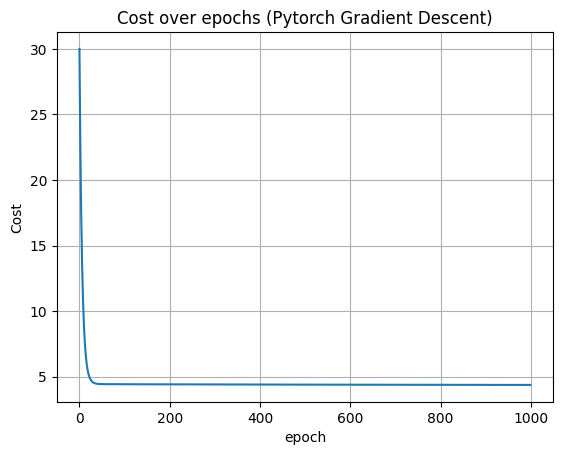

In [5]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(range(len(cost_history)), cost_history)
plt.title('Cost over epochs (Pytorch Gradient Descent)')
plt.xlabel('epoch')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

In [6]:
#   학습 전 값: 12번 셀에서 학습 시작 전에 저장해 둔 initial_a, initial_b, initial_cost를 사용합니다.
#   학습 후 값: 학습 반복문이 끝난 뒤 남아 있는 a, b가 곧 학습된 값입니다.(.item()으로 숫자 값을 꺼냄)
final_a = a.item()
final_b = b.item()
with torch.no_grad():
    final_cost = (torch.mean((y_tensor - (a * x_tensor + b)) ** 2)).item()
    
print('학습 전')
print(f'a = {initial_a:.4f}')
print(f'b = {initial_b:.4}')
print(f'Cost = {initial_cost:.4}')

print('학습 후')
print(f'a = {final_a:.4f}')
print(f'b = {final_b:.4}')
print(f'Cost = {final_cost:.4}')

학습 전
a = -4.0000
b = 80.0
Cost = 30.0
학습 후
a = -4.8061
b = 80.15
Cost = 4.361


In [7]:
#   학습된 a, b를 사용합니다. (Pytorch 텐서이므로, .item()으로 숫자 값을 꺼냅니다.)
final_a = a.item()
final_b = b.item()

new_X = 5                                   # 예측하고 싶은 새로운 기온(데이터에 없던 값)
predicted_y = final_a * new_X + final_b     # 학습된 직선에 새 기온을 넣어 예측(예측값 = a * X + b)

# 소수점 2자리로 보기 좋게 출력
print(f'학습된 식: y = {final_a:.2f}X + {final_b:.2f}')
print(f'기온이 {new_X}도일 때 예상 판매량: {predicted_y:.2f}개')


학습된 식: y = -4.81X + 80.15
기온이 5도일 때 예상 판매량: 56.11개


In [8]:
"""
----- run_gradient_descent 함수 설명 -----
입력값:
    learning_rate : 한 번에 얼마나 크게 수정할지 정하는 값 (보폭)
    epochs        : 전체 학습을 몇 번 반복할지 정하는 값
반환값:
    최종 a, 최종 b, 최종 Cost
    (12번의 Pytorch 학습 코드를, learning_rate를 바꿔 실험할 수 있게 함수로 묶은 것입니다.)
"""


def run_gradient_descent(learning_rate, epochs):
    a = torch.tensor(-4.0, requires_grad = True)
    b = torch.tensor(80.0, requires_grad = True)

    for epoch in range(epochs):
        pred = a * x_tensor + b
        error = y_tensor - pred         # error: 실제값 - 예측값
        cost = torch.mean(error ** 2)   # Cost : 오차 제곱 평균
        
        cost.backward()
        with torch.no_grad():
            a -= learning_rate * a.grad
            b -= learning_rate * b.grad
        a.grad.zero_()
        b.grad.zero_()
        
        if cost.item() > 1000000:
            print('Cost가 너무 커져 학습이 불안정해졌습니다. Learning Rate가 너무 클 수 있습니다.')
            return a.item(), b.item(), cost.item()
        
    return a.item(), b.item(), cost.item()

In [9]:
#   여러 learning_rate를 한꺼번에 비교해봅니다.(큰 값 → 작은 값 순서)
learning_rate = [0.1, 0.01, 0.001, 0.0001]

for lr in learning_rate:
    final_a, final_b, final_cost = run_gradient_descent(lr, 1000)
    print(f'learning_rate = {lr}, 최종 Cost = {final_cost:.4f}')
    print('-' * 40)

Cost가 너무 커져 학습이 불안정해졌습니다. Learning Rate가 너무 클 수 있습니다.
learning_rate = 0.1, 최종 Cost = 4147874.0000
----------------------------------------
learning_rate = 0.01, 최종 Cost = 4.3379
----------------------------------------
learning_rate = 0.001, 최종 Cost = 4.3613
----------------------------------------
learning_rate = 0.0001, 최종 Cost = 4.4137
----------------------------------------
